# Solving CartPole-v1 with PPO (from scratch)

This notebook demonstrates how to solve the CartPole-v1 environment using a custom implementation of the Proximal Policy Optimization (PPO) algorithm in PyTorch. No external RL libraries are used.

---

**Note:** All environment and hyperparameter settings are now collected in a single `CONFIG` dictionary at the top of the notebook. To change the environment or any hyperparameter, simply edit the values in the config cell.

## 1. Install and Import Required Libraries
We will use gymnasium and torch for this implementation.

In [12]:
# Install required packages
%pip install stable-baselines3 gymnasium tsilva-notebook-utils --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Set Up CartPole-v1 Environment
We will initialize the CartPole-v1 environment and display its basic information.

In [13]:
ENV_ID = "CartPole-v1"
#ENV_ID = "Acrobot-v1"
#ENV_ID = "LunarLander-v3"
#ENV_ID = "Pendulum-v1"
#ENV_ID = "MountainCar-v0"

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import numpy as np
import platform, os
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.utils import set_random_seed
import time  # <-- Added for wall time measurement

# --- Config dictionary for all hyperparameters and environment settings ---
def setup_config(env_id, normalize=False, max_envs=8):
    common = dict(
        env_id=env_id,         # Environment name
        seed=42,               # Random seed for reproducibility
        gamma=0.99,            # Discount factor for future rewards
        lam=0.95,              # GAE lambda for advantage estimation
        clip_epsilon=0.2,      # PPO clip range for policy update
        minibatch_size=64,     # Minibatch size for SGD
        episodes_per_epoch=20, # Number of episodes per training epoch
        eval_interval=5,       # Evaluate every N epochs
        eval_episodes=20,      # Number of episodes for evaluation
        reward_threshold=200,  # Reward threshold to consider environment solved
        policy_lr=3e-4,        # Learning rate for policy network
        value_lr=1e-3,         # Learning rate for value network
        hidden_dim=64,         # Hidden layer size for networks
        entropy_coef=0.01,     # Coefficient for entropy bonus (encourages exploration)
        normalize=normalize,   # Whether to use input normalization
        max_envs=max_envs      # Maximum number of parallel environments
    )
    env_specific = {
        "CartPole-v1": dict(
            gamma=0.99,           # Standard discount for CartPole
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for CartPole
            minibatch_size=32,    # Smaller batch for faster updates
            episodes_per_epoch=16,# Fewer episodes per epoch for quick feedback
            eval_interval=2,      # Evaluate more frequently for fast convergence
            eval_episodes=10,     # Fewer eval episodes for speed
            reward_threshold=475, # Official CartPole-v1 solved threshold
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=64,        # Small net is sufficient for CartPole
        ),
        "LunarLander-v3": dict(
            gamma=0.99,           # Standard discount for LunarLander
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for LunarLander
            minibatch_size=64,    # Larger batch for more stable updates
            episodes_per_epoch=8, # Fewer episodes per epoch (env is longer)
            eval_interval=2,      # Evaluate every 2 epochs
            eval_episodes=5,      # Fewer eval episodes for speed
            reward_threshold=200, # Solved threshold for LunarLander-v3
            policy_lr=1e-4,       # Lower LR for more complex env
            value_lr=5e-4,        # Lower LR for value net
            hidden_dim=128,       # Larger net for more complex env
        ),
        "Acrobot-v1": dict(
            gamma=0.99,           # Standard discount for Acrobot
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for Acrobot
            minibatch_size=32,    # Smaller batch for faster updates
            episodes_per_epoch=16,# Fewer episodes per epoch for quick feedback
            eval_interval=2,      # Evaluate more frequently for fast convergence
            eval_episodes=10,     # Fewer eval episodes for speed
            reward_threshold=-100, # Solved threshold for Acrobot-v1 (average reward > -100)
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=64,        # Small net is sufficient for Acrobot
        ),
        "Pendulum-v1": dict(
            gamma=0.99,           # Standard discount for Pendulum
            lam=0.95,             # GAE lambda, balances bias/variance
            clip_epsilon=0.2,     # PPO clip range, stable for Pendulum
            minibatch_size=64,    # Larger batch for continuous action
            episodes_per_epoch=8, # Fewer episodes per epoch (env is longer)
            eval_interval=2,      # Evaluate every 2 epochs
            eval_episodes=5,      # Fewer eval episodes for speed
            reward_threshold=-200, # Solved threshold for Pendulum-v1 (average reward > -200)
            policy_lr=3e-4,       # Standard PPO learning rate
            value_lr=1e-3,        # Slightly higher for value net
            hidden_dim=128,       # Larger net for continuous control
        ),
        "MountainCar-v0": dict(
            gamma=0.99,             # Discount factor (keep)
            lam=0.97,               # Slightly higher GAE lambda for more bias reduction
            clip_epsilon=0.15,      # Tighter PPO clip for more stable updates
            minibatch_size=16,      # Smaller minibatch for more frequent updates
            episodes_per_epoch=24,  # More episodes per epoch for better sampling
            eval_interval=2,        # Keep frequent evaluation
            eval_episodes=10,       # Keep
            reward_threshold=-110,  # Keep
            policy_lr=1e-4,         # Lower learning rate for more stable policy updates
            value_lr=5e-4,          # Lower value net LR for stability
            hidden_dim=128,         # Larger network for more capacity
            entropy_coef=0.02       # Slightly lower entropy for less randomness
        ),
    }
    if env_id not in env_specific:
        raise ValueError(f"Unsupported env_id: {env_id}")
    return {**common, **env_specific[env_id]}

# Set normalize=True to enable input normalization
CONFIG = setup_config(ENV_ID, normalize=True, max_envs=8)

# --- Runtime metadata (optional, for reproducibility/info) ---
def runtime_metadata():
    return {
        "python_version": platform.python_version(),
        "run_host": os.uname().nodename,
    }
CONFIG.update(runtime_metadata())

# --- Unified build_env function for all env construction (SB3 style, with subproc option) ---
def _build_env(env_id, normalize=False, seed=None, n_envs=1, use_subproc=False):
    vec_env_cls = SubprocVecEnv if use_subproc else DummyVecEnv
    env = make_vec_env(env_id, n_envs=n_envs, seed=seed, vec_env_cls=vec_env_cls)
    if normalize:
        env = VecNormalize(env, norm_obs=True, norm_reward=False)
    return env

# Set up the environment with SB3 wrappers if requested
CONFIG = setup_config(ENV_ID, normalize=True, max_envs=CONFIG.get('max_envs', 8))
CONFIG.update(runtime_metadata())

import multiprocessing

N_ENVS = min(multiprocessing.cpu_count(), CONFIG['max_envs'])  # Use up to CONFIG['max_envs']
USE_SUBPROC = True  # Use SubprocVecEnv for parallel rollout collection
set_random_seed(CONFIG['seed'], using_cuda=torch.cuda.is_available())

build_env = lambda seed: _build_env(CONFIG['env_id'], normalize=CONFIG.get('normalize', False), seed=seed, n_envs=N_ENVS, use_subproc=USE_SUBPROC)
env = build_env(CONFIG['seed'])
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


## 3. Implement PPO Agent
We will define the policy and value networks, and the PPO update step.

In [15]:
# Policy and Value Networks
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden_dim=None):
        super().__init__()
        h = hidden_dim or CONFIG['hidden_dim']
        self.net = nn.Sequential(
            nn.Linear(obs_dim, h), nn.Tanh(),
            nn.Linear(h, h), nn.Tanh(),
            nn.Linear(h, 1)
        )
    def forward(self, x):
        return self.net(x)

## 4. Train PPO Agent
We will train the PPO agent on CartPole-v1.

In [16]:
import torch
import gymnasium as gym
import numpy as np
from torch.distributions.categorical import Categorical


def collect_rollouts(policy, env, n_episodes=1, value_net=None, deterministic=False, render=False):
    """
    Collect rollouts using the given policy and environment.
    Returns: list of episode rewards, and (obs, actions, rewards, dones, logps, values) for all steps.
    Handles vectorized environments (n_envs > 1).
    """
    from torch.distributions.categorical import Categorical
    episode_rewards = []
    obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf = [], [], [], [], [], []
    obs = env.reset()
    if isinstance(obs, tuple):
        obs = obs[0]
    n_envs = obs.shape[0] if isinstance(obs, np.ndarray) and obs.ndim > 1 else 1
    ep_rews = [[] for _ in range(n_envs)]
    ep_obs, ep_acts, ep_rews_buf, ep_dones, ep_logps, ep_vals = [[] for _ in range(n_envs)], [[] for _ in range(n_envs)], [[] for _ in range(n_envs)], [[] for _ in range(n_envs)], [[] for _ in range(n_envs)], [[] for _ in range(n_envs)]
    episodes_collected = 0
    while episodes_collected < n_episodes:
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        logits = policy(obs_t)
        dist = Categorical(logits=logits)
        if deterministic:
            action = dist.probs.argmax(dim=-1)
        else:
            action = dist.sample()
        logp = dist.log_prob(action)
        value_pred = value_net(obs_t).squeeze(-1).detach().cpu().numpy() if value_net is not None else np.zeros(n_envs)
        step_result = env.step(action.cpu().numpy())
        if len(step_result) == 5:
            next_obs, reward, terminated, truncated, info = step_result
            done_flag = np.logical_or(terminated, truncated)
        else:
            next_obs, reward, done_flag, info = step_result
        for i in range(n_envs):
            ep_obs[i].append(obs[i])
            ep_acts[i].append(action[i].item())
            ep_logps[i].append(logp[i].item())
            ep_vals[i].append(value_pred[i] if n_envs > 1 else value_pred)
            ep_rews_buf[i].append(reward[i])
            ep_dones[i].append(done_flag[i])
            if done_flag[i]:
                episode_rewards.append(sum(ep_rews_buf[i]))
                obs_buf.extend(ep_obs[i])
                act_buf.extend(ep_acts[i])
                rew_buf.extend(ep_rews_buf[i])
                done_buf.extend(ep_dones[i])
                logp_buf.extend(ep_logps[i])
                val_buf.extend(ep_vals[i])
                ep_obs[i], ep_acts[i], ep_rews_buf[i], ep_dones[i], ep_logps[i], ep_vals[i] = [], [], [], [], [], []
                episodes_collected += 1
        if render:
            env.render()
        obs = next_obs
        if isinstance(obs, tuple):
            obs = obs[0]
    return episode_rewards, (obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf)

# TODO: generalize into method that can also render N episodes
def evaluate_policy(policy, env_name=None, n_episodes=None):
    n_episodes = n_episodes or CONFIG['eval_episodes']
    eval_seed = np.random.randint(0, 1000000)
    env = build_env(eval_seed)
    with torch.no_grad():
        episode_rewards, _ = collect_rollouts(policy, env, n_episodes=n_episodes, deterministic=True, render=False)
    mean_reward = np.mean(episode_rewards)
    return mean_reward, episode_rewards

evaluate_policy(PolicyNet(obs_dim, act_dim), n_episodes=5)

(np.float32(9.5),
 [np.float32(8.0),
  np.float32(9.0),
  np.float32(9.0),
  np.float32(9.0),
  np.float32(10.0),
  np.float32(10.0),
  np.float32(10.0),
  np.float32(10.0),
  np.float32(10.0),
  np.float32(10.0)])

In [ ]:
# Helper functions for PPO
import random
import torch.optim as optim
import time  # <-- Ensure time is imported for wall time

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = []
    gae = 0
    values = values + [0]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    return advantages

# Vectorized GAE for parallel envs

def compute_gae_vec(rewards, values, dones, gamma=0.99, lam=0.95, n_envs=1):
    advantages = []
    start = 0
    for _ in range(n_envs):
        # Find episode length for this env
        ep_len = 0
        for j in range(start, len(rewards)):
            ep_len += 1
            if dones[j]:
                break
        ep_adv = compute_gae(rewards[start:start+ep_len], values[start:start+ep_len], dones[start:start+ep_len], gamma, lam)
        advantages.extend(ep_adv)
        start += ep_len
    return advantages

# Set fixed seed for training
set_global_seed(CONFIG['seed'])
env = build_env(CONFIG['seed'])
obs = env.reset()

# PPO Training Loop
entropy_coef = CONFIG.get('entropy_coef', 0.0)
policy_net = PolicyNet(obs_dim, act_dim, hidden_dim=CONFIG['hidden_dim'])
value_net = ValueNet(obs_dim, hidden_dim=CONFIG['hidden_dim'])
policy_optim = optim.Adam(policy_net.parameters(), lr=CONFIG['policy_lr'])
value_optim = optim.Adam(value_net.parameters(), lr=CONFIG['value_lr'])

clip_epsilon = CONFIG['clip_epsilon']
minibatch_size = CONFIG['minibatch_size']
gamma = CONFIG['gamma']
lam = CONFIG['lam']
episodes_per_epoch = CONFIG['episodes_per_epoch']
eval_interval = CONFIG['eval_interval']
eval_episodes = CONFIG['eval_episodes']
reward_threshold = CONFIG['reward_threshold']

train_rewards = []  # Store mean reward per epoch
solved = False
current_epoch = 0

start_time = time.time()  # <-- Start wall time measurement

while not solved:
    # Use collect_rollouts for training
    episode_rewards, (obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf) = collect_rollouts(
        policy_net, env, n_episodes=episodes_per_epoch, value_net=value_net, deterministic=False, render=False)
    train_rewards.append(np.mean(episode_rewards))
    # Compute advantages per environment episode
    adv_buf = compute_gae_vec(rew_buf, val_buf, done_buf, gamma, lam, n_envs=N_ENVS)
    # Truncate val_buf to match adv_buf length (in case of partial episodes)
    val_buf_trunc = val_buf[:len(adv_buf)]
    ret_buf = (np.array(adv_buf) + np.array(val_buf_trunc)).tolist()
    # Convert buffers to tensors
    obs_tensor = torch.as_tensor(np.array(obs_buf[:len(adv_buf)]), dtype=torch.float32)
    act_tensor = torch.as_tensor(np.array(act_buf[:len(adv_buf)]), dtype=torch.int64)
    adv_tensor = torch.as_tensor(np.array(adv_buf), dtype=torch.float32)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32)
    logp_old_tensor = torch.as_tensor(np.array(logp_buf[:len(adv_buf)]), dtype=torch.float32)
    # Normalize advantages
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)
    # PPO update
    num_samples = len(obs_tensor)
    for _ in range(10):
        idx = np.random.permutation(num_samples)
        for start in range(0, num_samples, minibatch_size):
            end = min(start + minibatch_size, num_samples)
            mb_idx = idx[start:end]
            logits = policy_net(obs_tensor[mb_idx])
            dist = Categorical(logits=logits)
            logp = dist.log_prob(act_tensor[mb_idx])
            ratio = torch.exp(logp - logp_old_tensor[mb_idx])
            surr1 = ratio * adv_tensor[mb_idx]
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * adv_tensor[mb_idx]
            entropy = dist.entropy().mean()
            policy_loss = -torch.min(surr1, surr2).mean() - entropy_coef * entropy
            value_pred = value_net(obs_tensor[mb_idx]).squeeze()
            value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
            policy_optim.zero_grad()
            policy_loss.backward()
            policy_optim.step()
            value_optim.zero_grad()
            value_loss.backward()
            value_optim.step()
    current_epoch += 1
    print(f"Epoch {current_epoch} complete. Mean train reward: {train_rewards[-1]:.2f}")
    if current_epoch % eval_interval == 0:
        mean_eval_reward, _ = evaluate_policy(policy_net, n_episodes=eval_episodes)
        print(f"Evaluation after {current_epoch} epochs: Mean reward = {mean_eval_reward:.2f}")
        if mean_eval_reward >= reward_threshold:
            print(f"Solved! Mean evaluation reward {mean_eval_reward:.2f} >= {reward_threshold}")
            solved = True

end_time = time.time()  # <-- End wall time measurement
print(f"Total training wall time: {end_time - start_time:.2f} seconds")

Epoch 1 complete. Mean train reward: 16.12
Epoch 2 complete. Mean train reward: 22.35
Evaluation after 2 epochs: Mean reward = 94.90
Evaluation after 2 epochs: Mean reward = 94.90
Epoch 3 complete. Mean train reward: 17.19
Epoch 4 complete. Mean train reward: 23.44
Epoch 3 complete. Mean train reward: 17.19
Epoch 4 complete. Mean train reward: 23.44
Evaluation after 4 epochs: Mean reward = 57.20
Evaluation after 4 epochs: Mean reward = 57.20
Epoch 5 complete. Mean train reward: 34.00
Epoch 5 complete. Mean train reward: 34.00
Epoch 6 complete. Mean train reward: 44.19
Epoch 6 complete. Mean train reward: 44.19
Evaluation after 6 epochs: Mean reward = 195.10
Evaluation after 6 epochs: Mean reward = 195.10
Epoch 7 complete. Mean train reward: 72.25
Epoch 7 complete. Mean train reward: 72.25
Epoch 8 complete. Mean train reward: 140.81
Epoch 8 complete. Mean train reward: 140.81
Evaluation after 8 epochs: Mean reward = 235.10
Evaluation after 8 epochs: Mean reward = 235.10
Epoch 9 complete

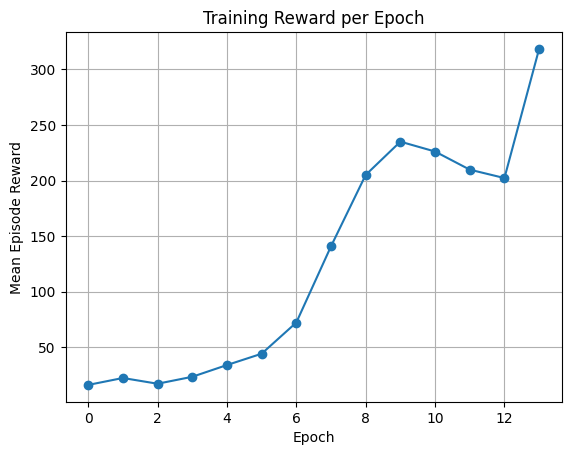

In [18]:
# Plot training rewards after training
import matplotlib.pyplot as plt
plt.plot(train_rewards, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Episode Reward')
plt.title('Training Reward per Epoch')
plt.grid(True)
plt.show()

In [19]:
# Evaluate the trained policy_net on 100 episodes
mean_reward, episode_rewards = evaluate_policy(policy_net, n_episodes=100)
print(f"Mean reward over 100 episodes: {mean_reward:.2f}")

Mean reward over 100 episodes: 500.00


In [20]:
from tsilva_notebook_utils.gymnasium import render_episode

# Use the trained policy_net and provide a callable that accepts env_kwargs and sets render_mode via gym.make

def make_env_for_render(env_kwargs=None):
    env_id = CONFIG['env_id']
    normalize = CONFIG.get('normalize', False)
    seed = CONFIG['seed']
    n_envs = 1
    use_subproc = False
    # Use gymnasium directly to set render_mode
    import gymnasium as gym
    render_mode = env_kwargs['render_mode'] if env_kwargs and 'render_mode' in env_kwargs else None
    env = gym.make(env_id, render_mode=render_mode)
    env.reset(seed=seed)
    if normalize:
        # VecNormalize expects a vectorized env, so skip normalization for rendering
        pass
    obs = env.reset()
    info = {}
    return env, obs, info

render_episode(
    env=make_env_for_render,
    model=policy_net
)